In [13]:
pip install nibabel matplotlib numpy scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\joeco\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
from pathlib import Path
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

project_root = Path("..").resolve()

train_dir = project_root / "data" / "Train"
subject = "subj001"
subject_dir = train_dir / subject

image_path = subject_dir / f"{subject}_image.nii.gz"
artifact_path = subject_dir / f"{subject}_artifact.nii.gz"
catheter_path = subject_dir / f"{subject}_catheter.nii.gz"
json_path = subject_dir / f"{subject}.json"

print(image_path.exists(), image_path)
print(artifact_path.exists(), artifact_path)
print(catheter_path.exists(), catheter_path)
print(json_path.exists(), json_path)

True C:\Users\joeco\Downloads\Valve-Artifact-Detection\data\Train\subj001\subj001_image.nii.gz
True C:\Users\joeco\Downloads\Valve-Artifact-Detection\data\Train\subj001\subj001_artifact.nii.gz
True C:\Users\joeco\Downloads\Valve-Artifact-Detection\data\Train\subj001\subj001_catheter.nii.gz
True C:\Users\joeco\Downloads\Valve-Artifact-Detection\data\Train\subj001\subj001.json


In [15]:
img = nib.load(image_path)
I = img.get_fdata()

artifact_img = nib.load(artifact_path)
A = artifact_img.get_fdata()

catheter_img = nib.load(catheter_path)
C = catheter_img.get_fdata()

print("MRI shape:", I.shape)
print("Artifact shape:", A.shape)
print("Catheter shape:", C.shape)

print("MRI min/max:", I.min(), I.max())
print("Artifact unique values:", np.unique(A))
print("Catheter unique values:", np.unique(C))

MRI shape: (192, 224, 192)
Artifact shape: (192, 224, 192)
Catheter shape: (192, 224, 192)
MRI min/max: 0.0 512.5097045898438
Artifact unique values: [0. 1.]
Catheter unique values: [0. 1. 2.]


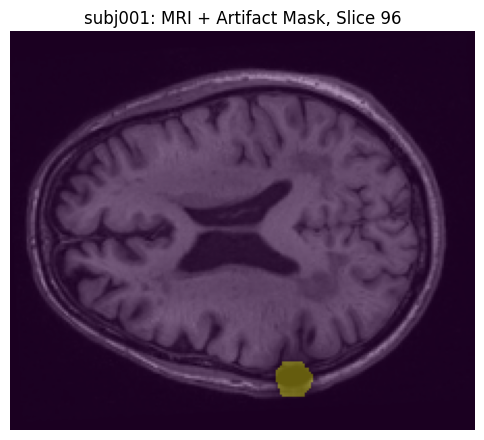

In [16]:
slice_idx = I.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(I[:, :, slice_idx], cmap="gray")
plt.imshow(A[:, :, slice_idx], alpha=0.4)
plt.axis("off")
plt.title(f"{subject}: MRI + Artifact Mask, Slice {slice_idx}")
plt.show()

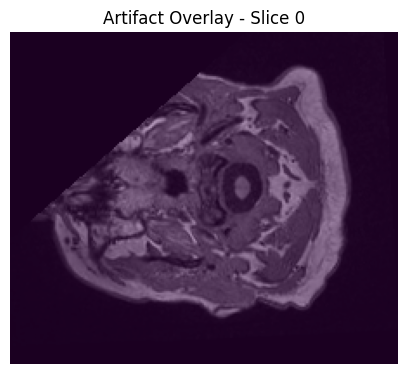

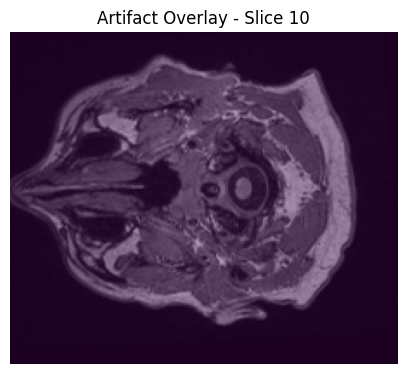

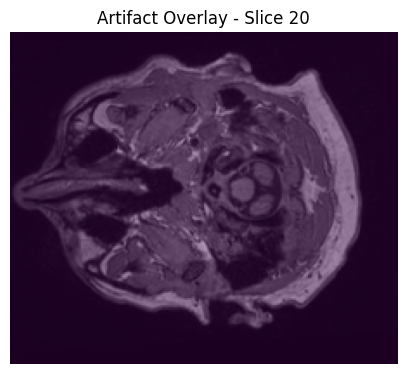

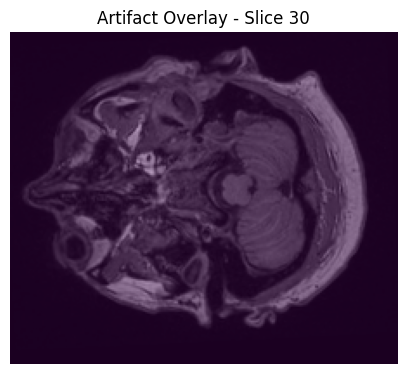

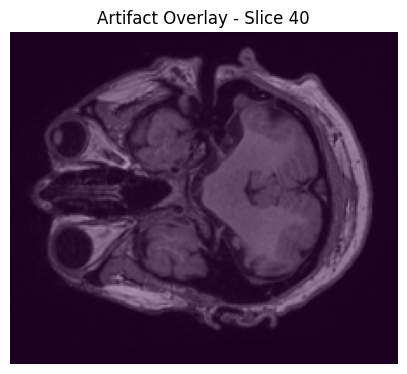

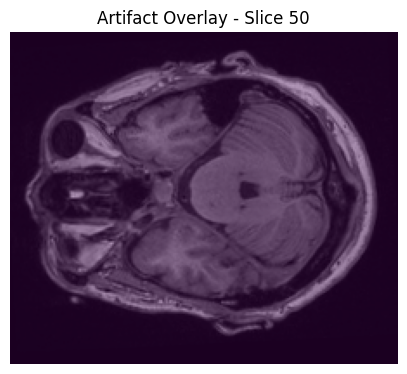

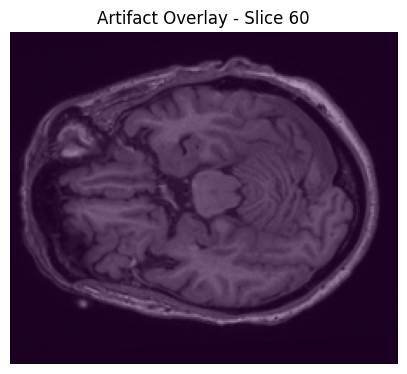

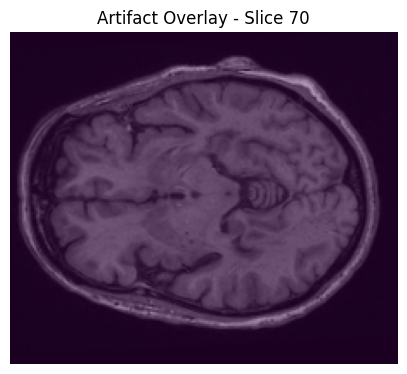

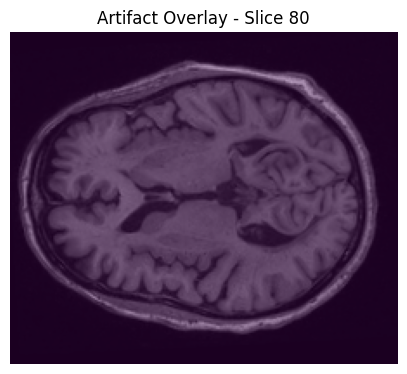

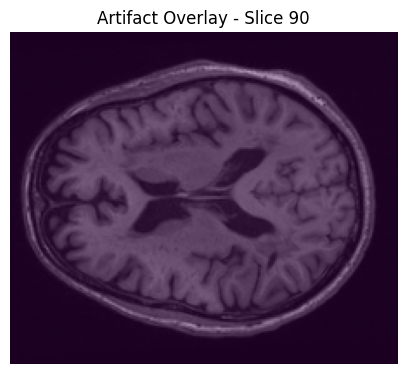

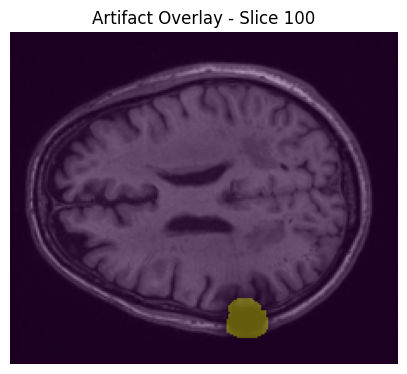

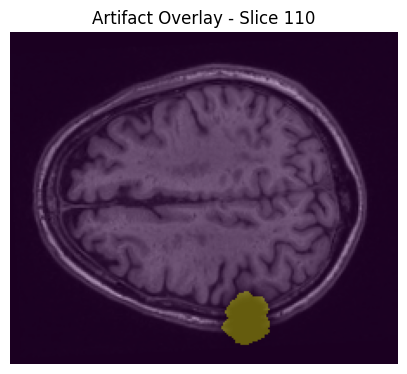

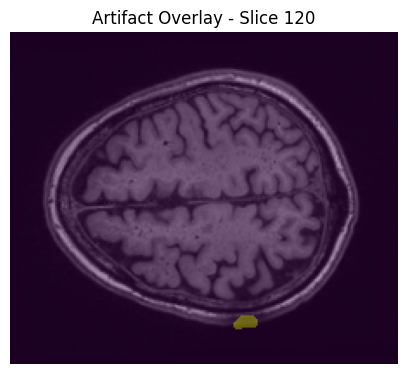

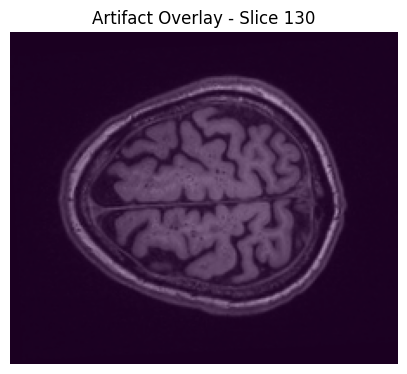

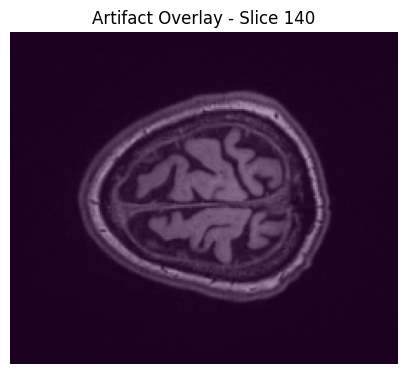

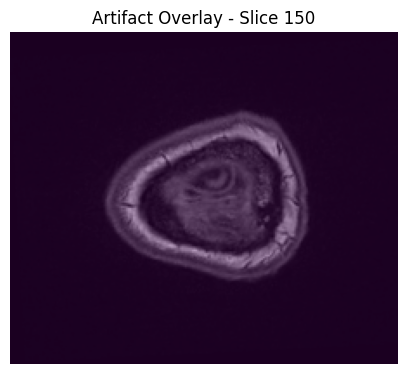

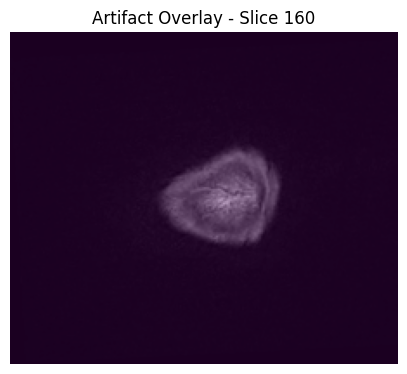

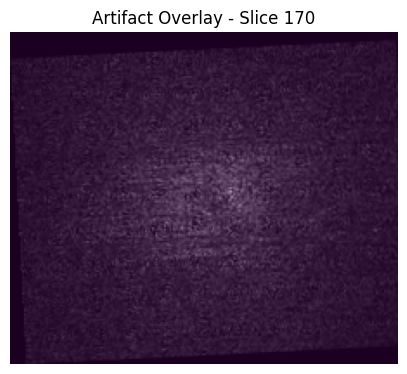

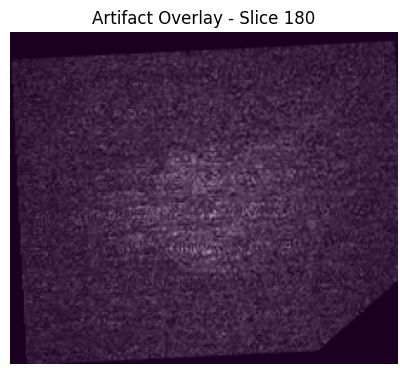

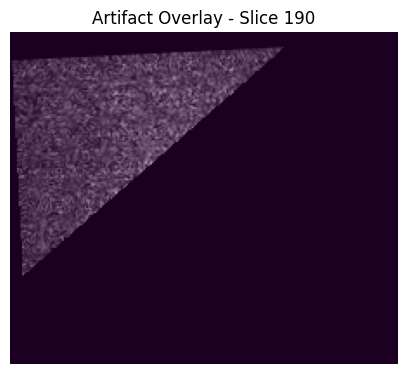

In [17]:
for i in range(0, I.shape[2], 10):
    plt.figure(figsize=(5, 5))
    plt.imshow(I[:, :, i], cmap="gray")
    plt.imshow(A[:, :, i], alpha=0.4)
    plt.axis("off")
    plt.title(f"Artifact Overlay - Slice {i}")
    plt.show()